# Enterprise Marketing Mix Modeling (MMM)
## Project Overview

This project aims to build an end-to-end Marketing Science platform using classical econometric methods, Bayesian inference, causal inference, forecasting, optimization, and deployment best practices.

### Objective
Measure the effectiveness of marketing channels, estimate their contribution to sales, optimize budget allocation, and forecast future business performance using Marketing Mix Modeling.

## Dataset Design

The dataset contains weekly observations with marketing investments, business KPIs, campaign information, external business factors, and economic indicators required for Marketing Mix Modeling, forecasting, causal inference, and budget optimization.

# Dataset Generation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from datetime import datetime

import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)

In [3]:
# Create weekly dates for 3 years

dates = pd.date_range(
    start="2022-01-02",
    periods=156,
    freq="W"
)

dates[:5]

DatetimeIndex(['2022-01-02', '2022-01-09', '2022-01-16', '2022-01-23',
               '2022-01-30'],
              dtype='datetime64[ns]', freq='W-SUN')

In [4]:
df = pd.DataFrame()
df["date"] = dates
df.head()

,date
0,2022-01-02
1,2022-01-09
2,2022-01-16
3,2022-01-23
4,2022-01-30


In [5]:
## Create Time Features
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["week"] = df["date"].dt.isocalendar().week.astype(int)
df["quarter"] = df["date"].dt.quarter

In [6]:
df.head()

,date,year,month,week,quarter
0,2022-01-02,2022,1,52,1
1,2022-01-09,2022,1,1,1
2,2022-01-16,2022,1,2,1
3,2022-01-23,2022,1,3,1
4,2022-01-30,2022,1,4,1


In [7]:
# Map months to seasons

season_map = {
    1: "Winter", 2: "Winter",
    3: "Spring", 4: "Spring", 5: "Spring",
    6: "Summer", 7: "Summer", 8: "Summer",
    9: "Monsoon", 10: "Monsoon",
    11: "Festive", 12: "Festive"
}

df["season"] = df["month"].map(season_map)

df.head()

,date,year,month,week,quarter,season
0,2022-01-02,2022,1,52,1,Winter
1,2022-01-09,2022,1,1,1,Winter
2,2022-01-16,2022,1,2,1,Winter
3,2022-01-23,2022,1,3,1,Winter
4,2022-01-30,2022,1,4,1,Winter


In [8]:
# Initialize holiday column
df["holiday"] = 0

# Major festive months
holiday_months = [10, 11, 12]

df.loc[df["month"].isin(holiday_months), "holiday"] = 1

df.head()

,date,year,month,week,quarter,season,holiday
0,2022-01-02,2022,1,52,1,Winter,0
1,2022-01-09,2022,1,1,1,Winter,0
2,2022-01-16,2022,1,2,1,Winter,0
3,2022-01-23,2022,1,3,1,Winter,0
4,2022-01-30,2022,1,4,1,Winter,0


In [9]:
# Default: no promotion
df["promotion"] = 0

# Promotion probability
promotion_weeks = np.random.choice(
    df.index,
    size=25,
    replace=False
)

df.loc[promotion_weeks, "promotion"] = 1

df.head()

,date,year,month,week,quarter,season,holiday,promotion
0,2022-01-02,2022,1,52,1,Winter,0,0
1,2022-01-09,2022,1,1,1,Winter,0,0
2,2022-01-16,2022,1,2,1,Winter,0,0
3,2022-01-23,2022,1,3,1,Winter,0,0
4,2022-01-30,2022,1,4,1,Winter,0,0


In [10]:
# Default discount
df["discount"] = 0

# Apply discounts only during promotions
df.loc[df["promotion"] == 1, "discount"] = np.random.randint(
    10,
    41,
    df["promotion"].sum()
)

df.head()

,date,year,month,week,quarter,season,holiday,promotion,discount
0,2022-01-02,2022,1,52,1,Winter,0,0,0
1,2022-01-09,2022,1,1,1,Winter,0,0,0
2,2022-01-16,2022,1,2,1,Winter,0,0,0
3,2022-01-23,2022,1,3,1,Winter,0,0,0
4,2022-01-30,2022,1,4,1,Winter,0,0,0


In [11]:
# Base weekly budget for each channel
channel_budget = {
    "tv_spend": 800000,
    "radio_spend": 150000,
    "search_spend": 450000,
    "facebook_spend": 300000,
    "instagram_spend": 250000,
    "youtube_spend": 350000,
    "display_spend": 180000,
    "email_spend": 80000,
    "affiliate_spend": 120000
}

# Different behaviour for every channel
channel_settings = {
    "tv_spend": {"trend": 60000, "season": 80000, "noise": 50000},
    "radio_spend": {"trend": 10000, "season": 25000, "noise": 35000},
    "search_spend": {"trend": 50000, "season": 15000, "noise": 45000},
    "facebook_spend": {"trend": 40000, "season": 50000, "noise": 40000},
    "instagram_spend": {"trend": 70000, "season": 30000, "noise": 45000},
    "youtube_spend": {"trend": 50000, "season": 70000, "noise": 35000},
    "display_spend": {"trend": 15000, "season": 10000, "noise": 30000},
    "email_spend": {"trend": 5000, "season": 5000, "noise": 25000},
    "affiliate_spend": {"trend": 20000, "season": 8000, "noise": 30000}
}
weeks = np.arange(len(df))
for channel, budget in channel_budget.items():
    settings = channel_settings[channel]
    trend = np.linspace(0, settings["trend"], len(df))
    seasonality = settings["season"] * np.sin(
        2 * np.pi * weeks / np.random.randint(20, 40)
    )
    noise = np.random.normal(0, settings["noise"], len(df))
    festival_boost = np.where(df["holiday"] == 1, budget * 0.15, 0)
    promotion_boost = np.where(df["promotion"] == 1, budget * 0.08, 0)
    df[channel] = (
        budget
        + trend
        + seasonality
        + noise
        + festival_boost
        + promotion_boost
    )
    df[channel] = df[channel].clip(lower=0)
df.head()

,date,year,month,week,quarter,season,holiday,promotion,discount,tv_spend,radio_spend,search_spend,facebook_spend,instagram_spend,youtube_spend,display_spend,email_spend,affiliate_spend
0,2022-01-02,2022,1,52,1,Winter,0,0,0,806350.611969,103560.888185,424653.362484,309680.605763,176668.315631,361123.180922,229709.654091,73116.919412,148057.144842
1,2022-01-09,2022,1,1,1,Winter,0,0,0,757060.163777,221065.045178,568471.466926,250569.708326,281734.590598,342843.319821,136190.372744,99891.509942,107788.050881
2,2022-01-16,2022,1,2,1,Winter,0,0,0,935207.828036,137053.083145,521000.872335,248262.014988,353750.730907,385936.575048,143113.987595,100843.092243,89127.153794
3,2022-01-23,2022,1,3,1,Winter,0,0,0,846544.280106,123074.027253,444028.376058,302321.918554,301801.686256,386559.104066,230047.546189,65601.853298,142244.541122
4,2022-01-30,2022,1,4,1,Winter,0,0,0,822037.735098,163599.980969,516013.742185,377785.268326,253559.665858,401853.708099,110113.074912,104012.382987,86486.199346


In [12]:
marketing_cols = [
    "tv_spend",
    "radio_spend",
    "search_spend",
    "facebook_spend",
    "instagram_spend",
    "youtube_spend",
    "display_spend",
    "email_spend",
    "affiliate_spend"
]

df[marketing_cols] = df[marketing_cols].round(2)

In [13]:
df["competitor_spend"] = np.random.normal(
    1200000,
    120000,
    len(df)
)
df["competitor_spend"] += np.where(
    df["holiday"] == 1,
    150000,
    0
)
df["competitor_spend"] = df["competitor_spend"].clip(lower=0)
df.head()

,date,year,month,week,quarter,season,holiday,promotion,discount,tv_spend,radio_spend,search_spend,facebook_spend,instagram_spend,youtube_spend,display_spend,email_spend,affiliate_spend,competitor_spend
0,2022-01-02,2022,1,52,1,Winter,0,0,0,806350.61,103560.89,424653.36,309680.61,176668.32,361123.18,229709.65,73116.92,148057.14,1.243337e+06
1,2022-01-09,2022,1,1,1,Winter,0,0,0,757060.16,221065.05,568471.47,250569.71,281734.59,342843.32,136190.37,99891.51,107788.05,1.130510e+06
2,2022-01-16,2022,1,2,1,Winter,0,0,0,935207.83,137053.08,521000.87,248262.01,353750.73,385936.58,143113.99,100843.09,89127.15,1.123399e+06
3,2022-01-23,2022,1,3,1,Winter,0,0,0,846544.28,123074.03,444028.38,302321.92,301801.69,386559.10,230047.55,65601.85,142244.54,1.042635e+06
4,2022-01-30,2022,1,4,1,Winter,0,0,0,822037.74,163599.98,516013.74,377785.27,253559.67,401853.71,110113.07,104012.38,86486.20,1.292772e+06


In [14]:
## Product Pricing
df["price"] = np.random.normal(
    500,
    20,
    len(df)
)
df["price"] = df["price"].round(2)

In [15]:
## Inflation & Consumer Confidence
df["inflation"] = np.random.normal(
    5.5,
    0.4,
    len(df)
)
df["consumer_confidence"] = np.random.normal(
    100,
    5,
    len(df)
)
df.head()

,date,year,month,week,quarter,season,holiday,promotion,discount,tv_spend,...,facebook_spend,instagram_spend,youtube_spend,display_spend,email_spend,affiliate_spend,competitor_spend,price,inflation,consumer_confidence
0,2022-01-02,2022,1,52,1,Winter,0,0,0,806350.61,...,309680.61,176668.32,361123.18,229709.65,73116.92,148057.14,1.243337e+06,517.14,5.204548,106.503687
1,2022-01-09,2022,1,1,1,Winter,0,0,0,757060.16,...,250569.71,281734.59,342843.32,136190.37,99891.51,107788.05,1.130510e+06,496.62,5.432778,99.068185
2,2022-01-16,2022,1,2,1,Winter,0,0,0,935207.83,...,248262.01,353750.73,385936.58,143113.99,100843.09,89127.15,1.123399e+06,484.32,5.947206,110.260831
3,2022-01-23,2022,1,3,1,Winter,0,0,0,846544.28,...,302321.92,301801.69,386559.10,230047.55,65601.85,142244.54,1.042635e+06,512.17,5.552583,104.090936
4,2022-01-30,2022,1,4,1,Winter,0,0,0,822037.74,...,377785.27,253559.67,401853.71,110113.07,104012.38,86486.20,1.292772e+06,477.16,4.936122,87.382563


In [16]:
pd.set_option("display.float_format", "{:.2f}".format)

In [17]:
# Round all numeric columns
df = df.round(2)

In [18]:
## Generate Sales
# Sales equation
df["sales"] = (
    5000
    + 0.0025 * df["tv_spend"]
    + 0.0035 * df["radio_spend"]
    + 0.0060 * df["search_spend"]
    + 0.0055 * df["facebook_spend"]
    + 0.0050 * df["instagram_spend"]
    + 0.0045 * df["youtube_spend"]
    + 0.0030 * df["display_spend"]
    + 0.0020 * df["email_spend"]
    + 0.0035 * df["affiliate_spend"]
    + 400 * df["promotion"]
    + 250 * df["holiday"]
    - 8 * df["price"]
    - 0.0008 * df["competitor_spend"]
    + 4 * df["consumer_confidence"]
    - 18 * df["inflation"]
    + np.random.normal(0, 250, len(df))
)
df["sales"] = df["sales"].round().astype(int)
df.head()

,date,year,month,week,quarter,season,holiday,promotion,discount,tv_spend,...,instagram_spend,youtube_spend,display_spend,email_spend,affiliate_spend,competitor_spend,price,inflation,consumer_confidence,sales
0,2022-01-02,2022,1,52,1,Winter,0,0,0,806350.61,...,176668.32,361123.18,229709.65,73116.92,148057.14,1243337.37,517.14,5.20,106.50,10365
1,2022-01-09,2022,1,1,1,Winter,0,0,0,757060.16,...,281734.59,342843.32,136190.37,99891.51,107788.05,1130510.36,496.62,5.43,99.07,11862
2,2022-01-16,2022,1,2,1,Winter,0,0,0,935207.83,...,353750.73,385936.58,143113.99,100843.09,89127.15,1123398.74,484.32,5.95,110.26,12890
3,2022-01-23,2022,1,3,1,Winter,0,0,0,846544.28,...,301801.69,386559.10,230047.55,65601.85,142244.54,1042635.27,512.17,5.55,104.09,11438
4,2022-01-30,2022,1,4,1,Winter,0,0,0,822037.74,...,253559.67,401853.71,110113.07,104012.38,86486.20,1292771.99,477.16,4.94,87.38,12114


In [19]:
## Generate Revenue
df["revenue"] = (df["sales"] * df["price"]).round(2)

In [20]:
## Generate Orders
df["orders"] = (
    df["sales"] * np.random.uniform(0.88, 0.96, len(df))
).round().astype(int)

In [21]:
## Generate Profit
cost_per_unit = 320

df["profit"] = (
    (df["price"] - cost_per_unit) * df["sales"]
).round(2)

In [22]:
## Create Trend Variable
df["trend"] = np.arange(len(df))

In [23]:
print(df.shape)
df.head()

(156, 27)


,date,year,month,week,quarter,season,holiday,promotion,discount,tv_spend,...,affiliate_spend,competitor_spend,price,inflation,consumer_confidence,sales,revenue,orders,profit,trend
0,2022-01-02,2022,1,52,1,Winter,0,0,0,806350.61,...,148057.14,1243337.37,517.14,5.20,106.50,10365,5360156.10,9783,2043356.10,0
1,2022-01-09,2022,1,1,1,Winter,0,0,0,757060.16,...,107788.05,1130510.36,496.62,5.43,99.07,11862,5890906.44,11023,2095066.44,1
2,2022-01-16,2022,1,2,1,Winter,0,0,0,935207.83,...,89127.15,1123398.74,484.32,5.95,110.26,12890,6242884.80,12213,2118084.80,2
3,2022-01-23,2022,1,3,1,Winter,0,0,0,846544.28,...,142244.54,1042635.27,512.17,5.55,104.09,11438,5858200.46,10155,2198040.46,3
4,2022-01-30,2022,1,4,1,Winter,0,0,0,822037.74,...,86486.20,1292771.99,477.16,4.94,87.38,12114,5780316.24,11202,1903836.24,4


In [24]:
## Data Cleaning
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 27 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   date                 156 non-null    datetime64[ns]
 1   year                 156 non-null    int32         
 2   month                156 non-null    int32         
 3   week                 156 non-null    int64         
 4   quarter              156 non-null    int32         
 5   season               156 non-null    object        
 6   holiday              156 non-null    int64         
 7   promotion            156 non-null    int64         
 8   discount             156 non-null    int64         
 9   tv_spend             156 non-null    float64       
 10  radio_spend          156 non-null    float64       
 11  search_spend         156 non-null    float64       
 12  facebook_spend       156 non-null    float64       
 13  instagram_spend      156 non-null  

In [25]:
df.isnull().sum()

date                   0
year                   0
month                  0
week                   0
quarter                0
season                 0
holiday                0
promotion              0
discount               0
tv_spend               0
radio_spend            0
search_spend           0
facebook_spend         0
instagram_spend        0
youtube_spend          0
display_spend          0
email_spend            0
affiliate_spend        0
competitor_spend       0
price                  0
inflation              0
consumer_confidence    0
sales                  0
revenue                0
orders                 0
profit                 0
trend                  0
dtype: int64

In [26]:
df.duplicated().sum()

np.int64(0)

In [27]:
df.describe()

,date,year,month,week,quarter,holiday,promotion,discount,tv_spend,radio_spend,...,affiliate_spend,competitor_spend,price,inflation,consumer_confidence,sales,revenue,orders,profit,trend
count,156,156.00,156.00,156.00,156.00,156.00,156.00,156.00,156.00,156.00,...,156.00,156.00,156.00,156.00,156.00,156.00,156.00,156.00,156.00,156.00
mean,2023-06-28 12:00:00,2022.99,6.48,26.50,2.50,0.25,0.16,4.46,867770.05,168768.72,...,135737.74,1236308.97,501.04,5.53,100.74,12595.94,6307550.89,11593.21,2276851.41,77.50
min,2022-01-02 00:00:00,2022.00,1.00,1.00,1.00,0.00,0.00,0.00,604481.41,60315.90,...,67353.82,863253.95,449.65,4.56,87.38,10056.00,4908333.60,9032.00,1638620.82,0.00
25%,2022-09-30 06:00:00,2022.00,3.75,13.75,1.75,0.00,0.00,0.00,821829.90,136741.95,...,115492.54,1136346.23,488.33,5.23,97.55,11643.50,5871215.29,10786.00,2042663.88,38.75
50%,2023-06-28 12:00:00,2023.00,6.50,26.50,2.50,0.00,0.00,0.00,869108.84,173135.43,...,136954.27,1232391.49,499.63,5.54,100.89,12544.50,6256025.20,11541.00,2210613.02,77.50
75%,2024-03-25 18:00:00,2024.00,9.25,39.25,3.25,0.25,0.00,0.00,926395.69,200014.36,...,154475.62,1313447.66,516.25,5.80,103.40,13322.75,6682235.34,12246.75,2478580.05,116.25
max,2024-12-22 00:00:00,2024.00,12.00,52.00,4.00,1.00,1.00,39.00,1075247.90,280511.96,...,239561.32,1593996.64,549.69,6.80,112.19,15648.00,7967251.48,14612.00,3256774.51,155.00
std,NaN,0.82,3.46,15.06,1.12,0.43,0.37,10.99,84940.40,43844.69,...,30466.44,136490.31,20.71,0.43,4.77,1267.42,653547.94,1159.27,329825.20,45.18


In [28]:
df.shape

(156, 27)

# Exploratory Data Analysis (EDA)

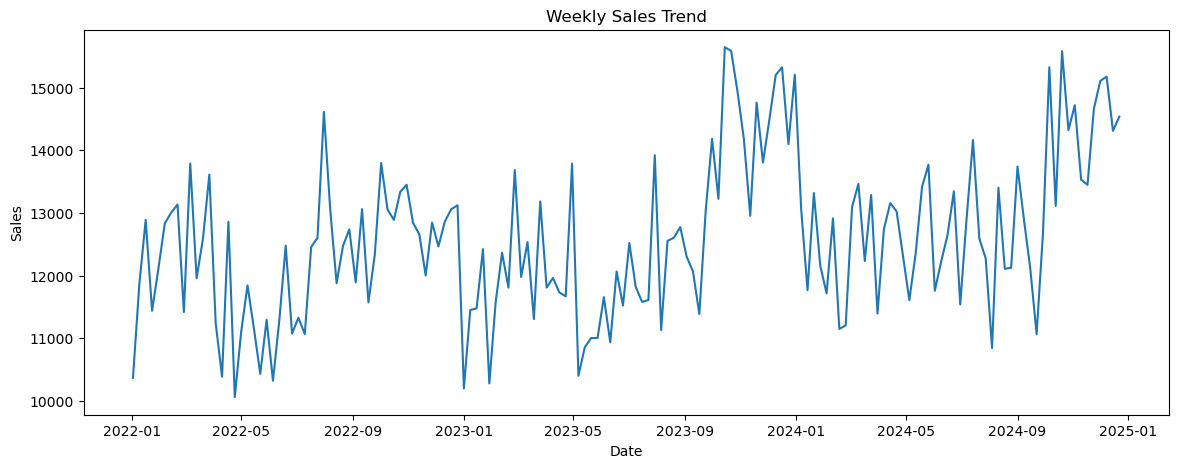

In [29]:
## Sales Trend Analysis
plt.figure(figsize=(14,5))
plt.plot(df["date"], df["sales"])
plt.title("Weekly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

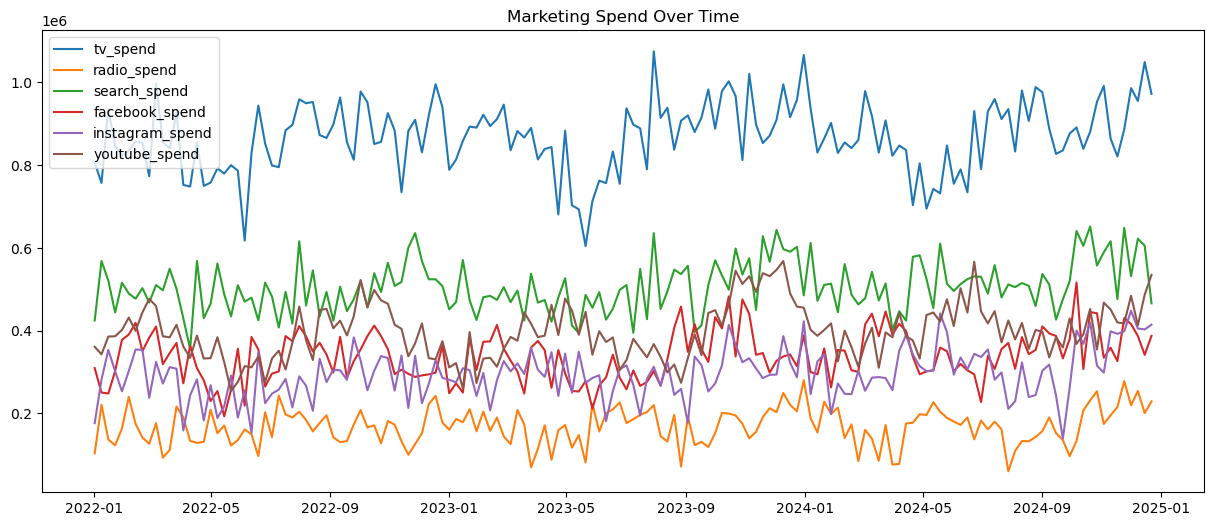

In [30]:
## Marketing Spend Trend
channels = [
    "tv_spend",
    "radio_spend",
    "search_spend",
    "facebook_spend",
    "instagram_spend",
    "youtube_spend",
]
plt.figure(figsize=(15,6))
for channel in channels:
    plt.plot(df["date"], df[channel], label=channel)
plt.legend()
plt.title("Marketing Spend Over Time")
plt.show()

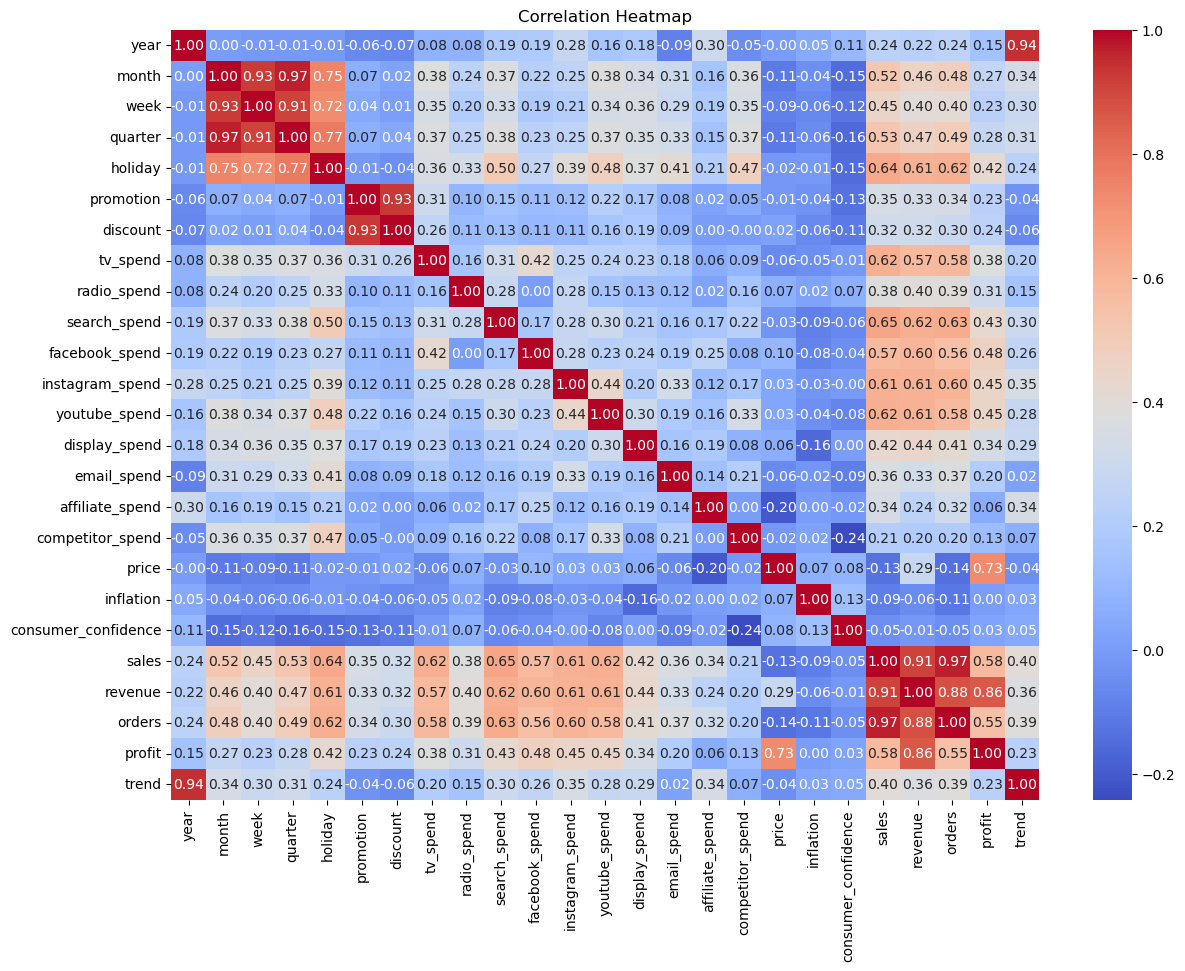

In [31]:
## Correlation Analysis
plt.figure(figsize=(14,10))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)
plt.title("Correlation Heatmap")
plt.show()

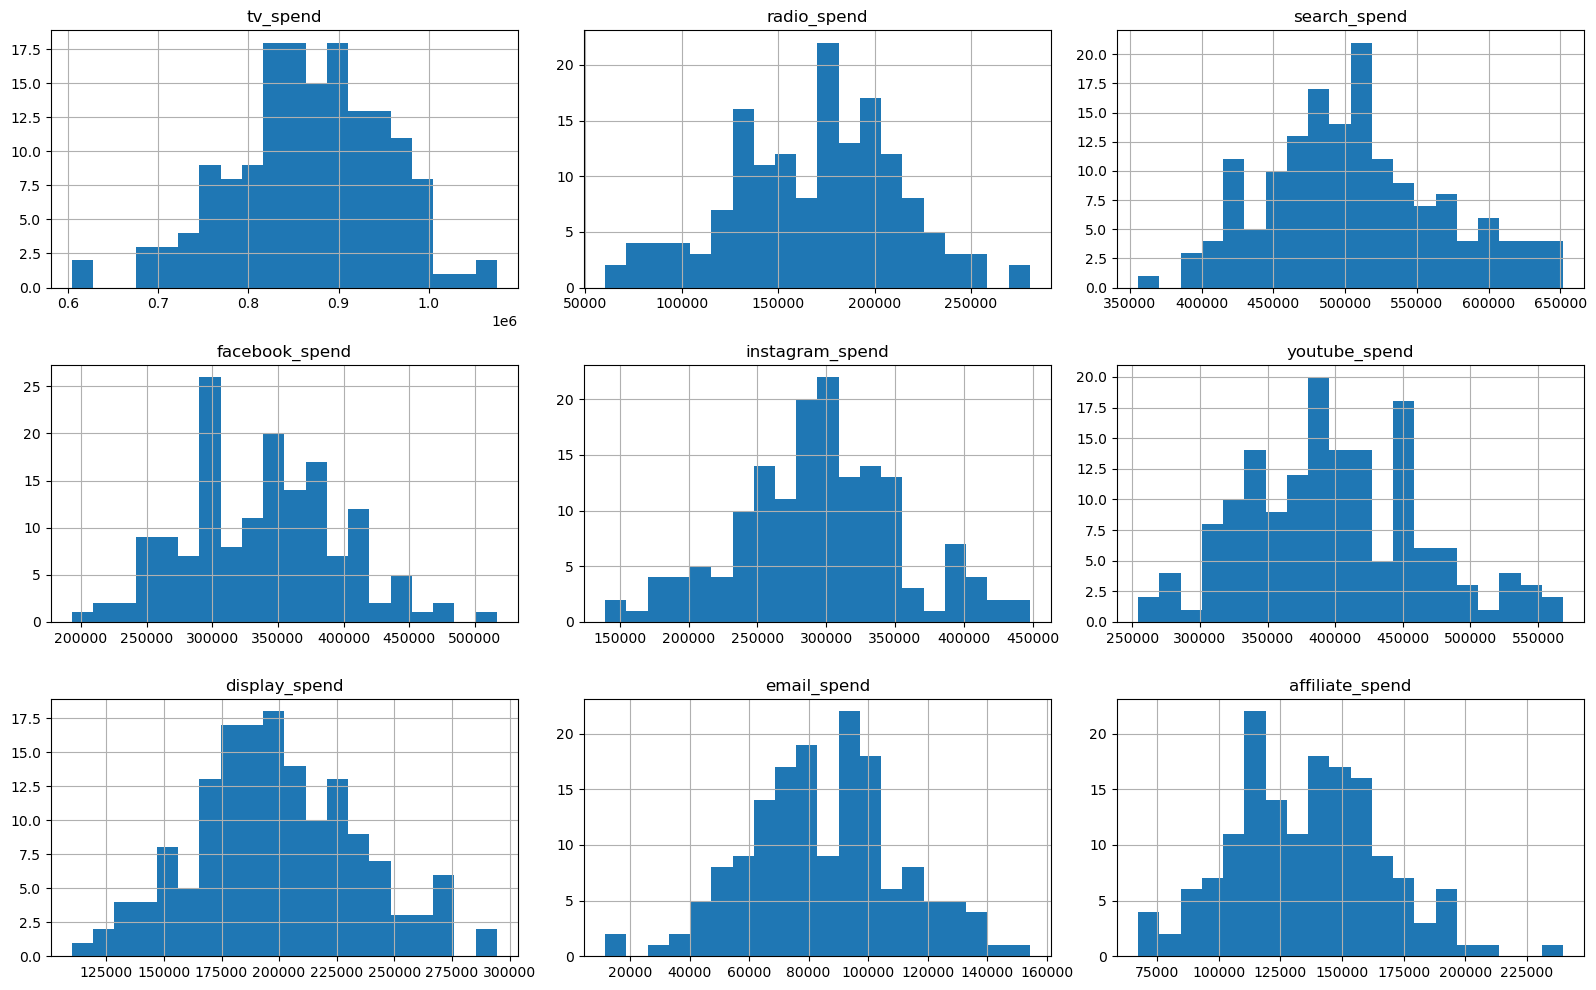

In [32]:
## Marketing Channel Distribution
channels = [
    "tv_spend",
    "radio_spend",
    "search_spend",
    "facebook_spend",
    "instagram_spend",
    "youtube_spend",
    "display_spend",
    "email_spend",
    "affiliate_spend"
]
df[channels].hist(figsize=(16,10), bins=20)
plt.tight_layout()
plt.show()

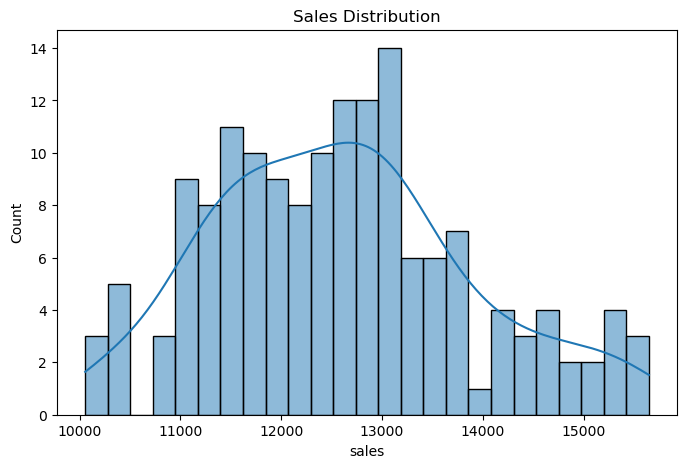

In [33]:
## Sales Distribution
plt.figure(figsize=(8,5))
sns.histplot(df["sales"], bins=25, kde=True)
plt.title("Sales Distribution")
plt.show()

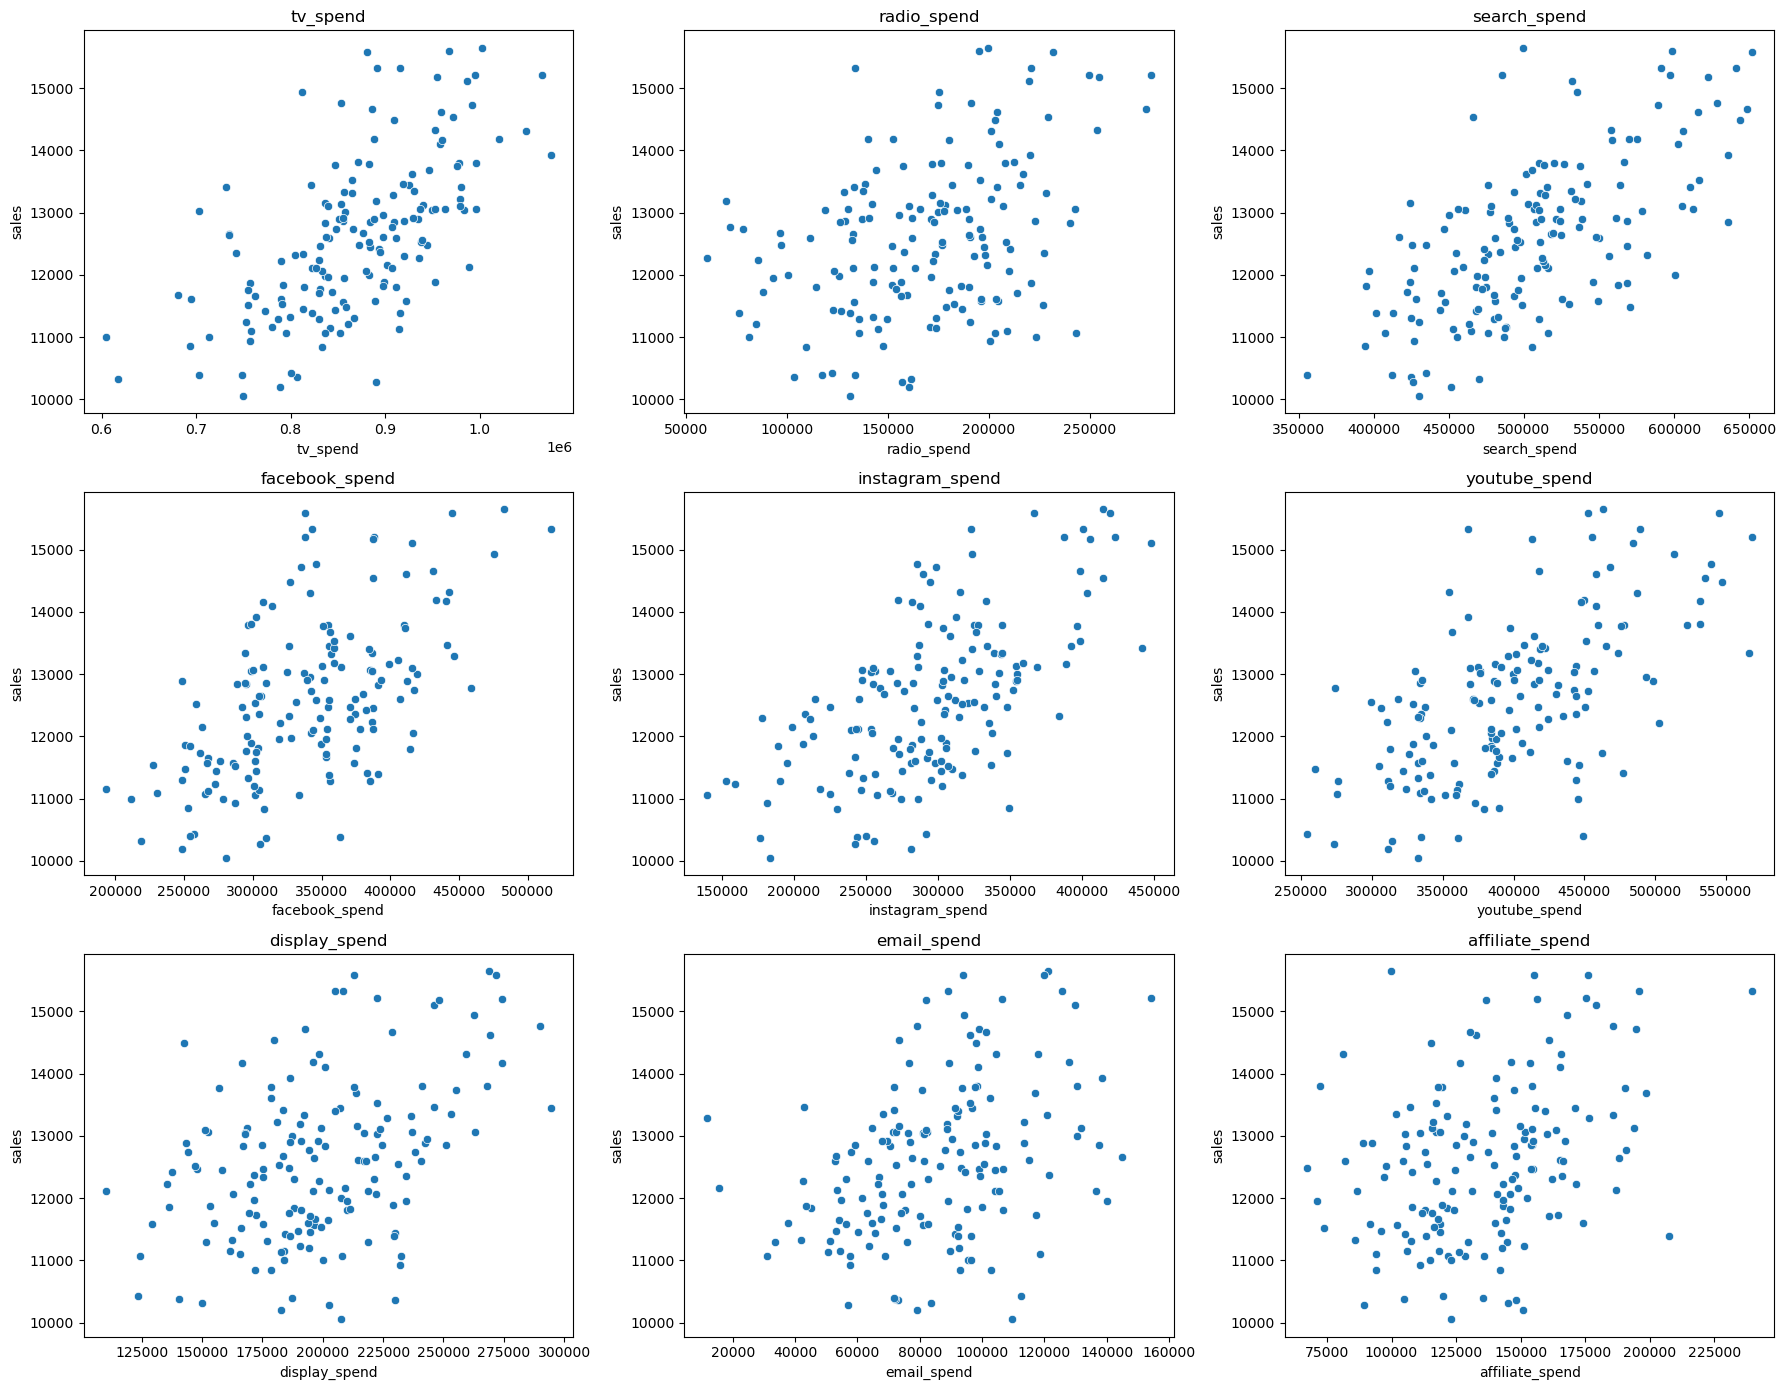

In [34]:
## Marketing Spend vs Sales
fig, axes = plt.subplots(3,3, figsize=(18,14))
axes = axes.flatten()
for i, channel in enumerate(channels):
    sns.scatterplot(
        x=df[channel],
        y=df["sales"],
        ax=axes[i]
    )
    axes[i].set_title(channel)
plt.tight_layout()
plt.show()

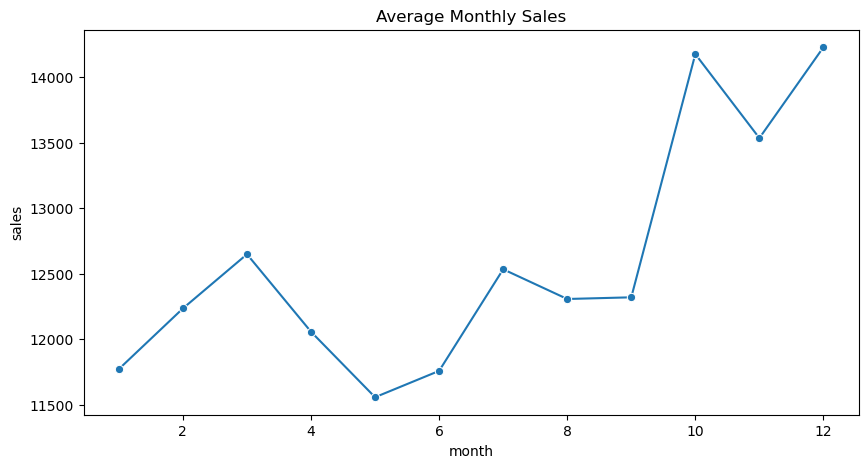

In [35]:
## Monthly Sales Trend
monthly_sales = (
    df.groupby("month")["sales"]
      .mean()
      .reset_index()
)
plt.figure(figsize=(10,5))
sns.lineplot(
    data=monthly_sales,
    x="month",
    y="sales",
    marker="o"
)
plt.title("Average Monthly Sales")
plt.show()

In [36]:
## Marketing Spend Summary
spend_summary = (
    df[channels]
    .sum()
    .sort_values(ascending=False)
)
spend_summary

tv_spend          135372128.19
search_spend       79050911.65
youtube_spend      62135499.11
facebook_spend     52866073.27
instagram_spend    46148086.42
display_spend      31024949.27
radio_spend        26327920.23
affiliate_spend    21175087.59
email_spend        13289390.32
dtype: float64

In [37]:
## Initial ROI Analysis
roi = pd.DataFrame({
    "Channel": channels,
    "Total Spend": [df[c].sum() for c in channels]
})
roi["ROI"] = (
    df["revenue"].sum() /
    roi["Total Spend"]
).round(2)
roi

,Channel,Total Spend,ROI
0,tv_spend,135372128.19,7.27
1,radio_spend,26327920.23,37.37
2,search_spend,79050911.65,12.45
3,facebook_spend,52866073.27,18.61
4,instagram_spend,46148086.42,21.32
5,youtube_spend,62135499.11,15.84
6,display_spend,31024949.27,31.72
7,email_spend,13289390.32,74.04
8,affiliate_spend,21175087.59,46.47


Key Business Insights
- Sales show an overall increasing trend with seasonal fluctuations.
- Marketing spend varies across channels and increases during promotional periods.
- Some channels have stronger relationships with sales than others.
- Holiday and promotion periods positively impact sales.
- The dataset is ready for econometric and Bayesian Marketing Mix Modeling.

# Econometric Regression
In this phase, we build our first regression model to understand how different marketing channels and business factors affect sales. 
This will act as our baseline model before moving to Adstock and Bayesian MMM.

In [38]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [39]:
y = df["sales"]

In [40]:
X = df[
    [
        "tv_spend",
        "radio_spend",
        "search_spend",
        "facebook_spend",
        "instagram_spend",
        "youtube_spend",
        "display_spend",
        "email_spend",
        "affiliate_spend",
        "price",
        "promotion",
        "holiday",
        "competitor_spend",
        "inflation",
        "consumer_confidence"
    ]
]

In [41]:
X = sm.add_constant(X)

In [42]:
model = sm.OLS(y, X).fit()

In [43]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.961
Model:                            OLS   Adj. R-squared:                  0.957
Method:                 Least Squares   F-statistic:                     230.4
Date:                Mon, 20 Jul 2026   Prob (F-statistic):           1.19e-90
Time:                        10:18:22   Log-Likelihood:                -1082.2
No. Observations:                 156   AIC:                             2196.
Df Residuals:                     140   BIC:                             2245.
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                5265.6944    

## Regression Results

The regression model explains the relationship between marketing channels, business factors, and sales. We evaluate the model using R², p-values, and regression coefficients.

## Multicollinearity Check (VIF)

We calculate the Variance Inflation Factor (VIF) to check whether any independent variables are highly correlated with each other.

In [44]:
# Remove constant column before calculating VIF
X_vif = X.drop("const", axis=1)

# Create VIF table
vif = pd.DataFrame()
vif["Feature"] = X_vif.columns
vif["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]
# Round values
vif["VIF"] = vif["VIF"].round(2)
# Display
vif.sort_values(by="VIF", ascending=False)

,Feature,VIF
9,price,432.44
14,consumer_confidence,408.60
13,inflation,174.22
0,tv_spend,150.41
12,competitor_spend,102.06
2,search_spend,96.24
5,youtube_spend,61.01
3,facebook_spend,48.69
6,display_spend,41.55
4,instagram_spend,37.63


Some predictors show high VIF values due to shared trends in marketing and macroeconomic variables. Since these variables are important from a business perspective, they are retained. In later phases, Bayesian Marketing Mix Modeling helps reduce the impact of multicollinearity through probabilistic estimation.

In [45]:
## Adstock Transformation
def adstock_transform(spend, decay):
    adstock = []
    for i, value in enumerate(spend):
        if i == 0:
            adstock.append(value)
        else:
            adstock.append(value + decay * adstock[i - 1])
    return adstock

In [46]:
## Apply Adstock
decay_rates = {
    "tv_spend": 0.80,
    "radio_spend": 0.50,
    "search_spend": 0.30,
    "facebook_spend": 0.60,
    "instagram_spend": 0.55,
    "youtube_spend": 0.70,
    "display_spend": 0.40,
    "email_spend": 0.20,
    "affiliate_spend": 0.35
}

In [47]:
for channel, decay in decay_rates.items():
    df[channel + "_adstock"] = adstock_transform(df[channel], decay)

In [48]:
adstock_cols = [col for col in df.columns if "_adstock" in col]

df[adstock_cols].head()

,tv_spend_adstock,radio_spend_adstock,search_spend_adstock,facebook_spend_adstock,instagram_spend_adstock,youtube_spend_adstock,display_spend_adstock,email_spend_adstock,affiliate_spend_adstock
0,806350.61,103560.89,424653.36,309680.61,176668.32,361123.18,229709.65,73116.92,148057.14
1,1402140.65,272845.49,695867.48,436378.08,378902.17,595629.55,228074.23,114514.89,159608.05
2,2056920.35,273475.83,729761.11,510088.86,562146.92,802877.26,234343.68,123746.07,144989.97
3,2492080.56,259811.94,662956.71,608375.23,610982.50,948573.18,323785.02,90351.06,192991.03
4,2815702.19,293505.95,714900.75,742810.41,589600.04,1065854.94,239627.08,122082.59,154033.06


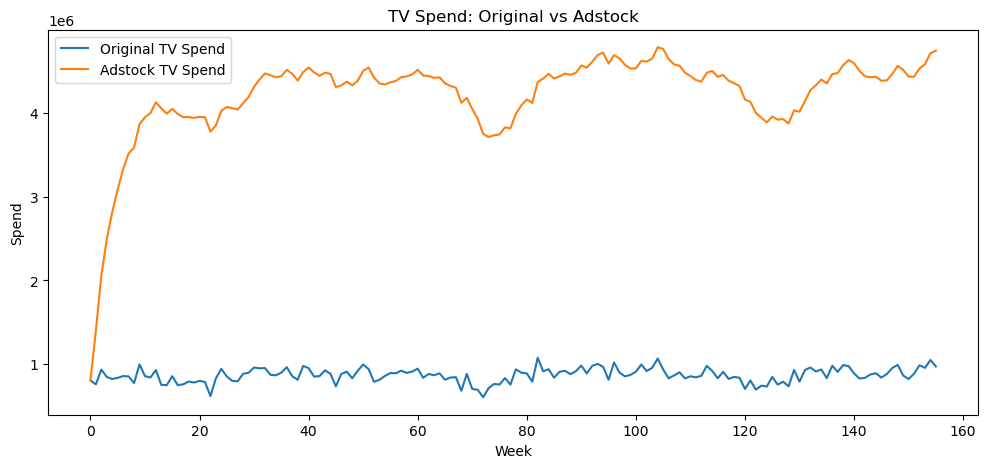

In [49]:
plt.figure(figsize=(12,5))

plt.plot(df["tv_spend"], label="Original TV Spend")
plt.plot(df["tv_spend_adstock"], label="Adstock TV Spend")

plt.title("TV Spend: Original vs Adstock")
plt.xlabel("Week")
plt.ylabel("Spend")
plt.legend()

plt.show()

In [50]:
df[adstock_cols] = df[adstock_cols].round(2)
df[adstock_cols].head()

,tv_spend_adstock,radio_spend_adstock,search_spend_adstock,facebook_spend_adstock,instagram_spend_adstock,youtube_spend_adstock,display_spend_adstock,email_spend_adstock,affiliate_spend_adstock
0,806350.61,103560.89,424653.36,309680.61,176668.32,361123.18,229709.65,73116.92,148057.14
1,1402140.65,272845.50,695867.48,436378.08,378902.17,595629.55,228074.23,114514.89,159608.05
2,2056920.35,273475.83,729761.11,510088.86,562146.92,802877.26,234343.68,123746.07,144989.97
3,2492080.56,259811.94,662956.71,608375.23,610982.50,948573.18,323785.02,90351.06,192991.03
4,2815702.19,293505.95,714900.75,742810.41,589600.04,1065854.94,239627.08,122082.59,154033.06


Observation
The Adstock curve is smoother than the original spend because it includes the carryover effect of previous advertising. Instead of using only the current week's spend, it also captures the remaining impact from earlier campaigns.

In [51]:
## Hill Saturation
def hill_saturation(x, alpha, gamma):
    return (x ** alpha) / (x ** alpha + gamma ** alpha)

In [52]:
hill_params = {
    "tv_spend_adstock": (1.5, 1500000),
    "radio_spend_adstock": (1.3, 300000),
    "search_spend_adstock": (1.8, 700000),
    "facebook_spend_adstock": (1.6, 500000),
    "instagram_spend_adstock": (1.5, 450000),
    "youtube_spend_adstock": (1.7, 800000),
    "display_spend_adstock": (1.2, 250000),
    "email_spend_adstock": (1.1, 100000),
    "affiliate_spend_adstock": (1.2, 180000)
}

for channel, (alpha, gamma) in hill_params.items():

    new_col = channel.replace("_adstock", "_hill")

    df[new_col] = hill_saturation(
        df[channel],
        alpha,
        gamma
    )

In [53]:
hill_cols = [col for col in df.columns if "_hill" in col]

df[hill_cols].head().round(4)

,tv_spend_hill,radio_spend_hill,search_spend_hill,facebook_spend_hill,instagram_spend_hill,youtube_spend_hill,display_spend_hill,email_spend_hill,affiliate_spend_hill
0,0.28,0.20,0.29,0.32,0.20,0.21,0.47,0.41,0.44
1,0.47,0.47,0.50,0.45,0.44,0.38,0.47,0.54,0.46
2,0.62,0.47,0.52,0.51,0.58,0.50,0.48,0.56,0.44
3,0.68,0.45,0.48,0.58,0.61,0.57,0.58,0.47,0.52
4,0.72,0.49,0.51,0.65,0.60,0.62,0.49,0.55,0.45


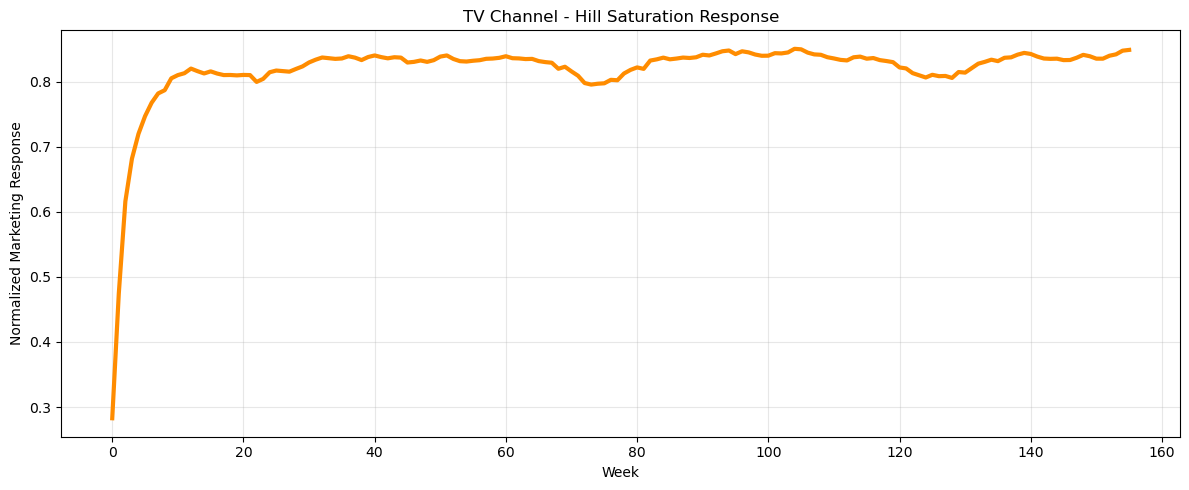

In [54]:
plt.figure(figsize=(12,5))

plt.plot(df["tv_spend_hill"], linewidth=3, color="darkorange")

plt.title("TV Channel - Hill Saturation Response")
plt.xlabel("Week")
plt.ylabel("Normalized Marketing Response")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

## Bayesian Marketing Mix Modeling

Classical regression gives a single estimate for each marketing channel. Bayesian MMM goes one step further by estimating a probability distribution for every parameter, allowing us to quantify uncertainty and make more reliable marketing decisions.

In [55]:
import pymc as pm
import arviz as az

g++ not available, if using conda: `conda install gxx`


In [56]:
print("PyMC Version :", pm.__version__)
print("ArviZ Version:", az.__version__)

PyMC Version : 6.0.1
ArviZ Version: 1.2.0


In [57]:
with pm.Model() as demo_model:

    beta = pm.Normal(
        "beta",
        mu=0,
        sigma=1
    )

## Building the Bayesian MMM

We define prior distributions for the model parameters and estimate their posterior distributions using the NUTS sampler provided by PyMC.

In [58]:
features = [
    "tv_spend_hill",
    "radio_spend_hill",
    "search_spend_hill",
    "facebook_spend_hill",
    "instagram_spend_hill",
    "youtube_spend_hill",
    "display_spend_hill",
    "email_spend_hill",
    "affiliate_spend_hill",
    "price",
    "promotion",
    "holiday",
    "competitor_spend"
]

X = df[features].values

y = df["sales"].values

In [59]:
from sklearn.preprocessing import StandardScaler

x_scaler = StandardScaler()
y_scaler = StandardScaler()
X_scaled = x_scaler.fit_transform(X)
y_scaled = y_scaler.fit_transform(y.reshape(-1,1)).flatten()

In [60]:
with pm.Model() as bayesian_mmm:
    intercept = pm.Normal(
        "intercept",
        mu=0,
        sigma=1
    )
    beta = pm.Normal(
        "beta",
        mu=0,
        sigma=1,
        shape=X_scaled.shape[1]
    )
    sigma = pm.HalfNormal(
        "sigma",
        sigma=1
    )
    mu = intercept + pm.math.dot(X_scaled, beta)
    likelihood = pm.Normal(
        "sales",
        mu=mu,
        sigma=sigma,
        observed=y_scaled
    )

In [61]:
## Bayesian Inference using MCMC Sampling
with bayesian_mmm:

    trace = pm.sample(
        draws=2000,
        tune=1000,
        chains=4,
        cores=4,
        target_accept=0.95,
        random_seed=42
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept, beta, sigma]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 20 seconds.


In [62]:
summary = az.summary(trace, ci_prob=0.95)

summary

,mean,sd,eti95_lb,eti95_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
intercept,0.0001,0.0341,-0.065,0.069,10857,6138,1.00,0.00033,0.00023
beta[0],-0.551,0.069,-0.69,-0.42,4955,5166,1.00,0.00098,0.00071
beta[1],0.1151,0.0433,0.031,0.2,7795,6188,1.00,0.00049,0.00036
beta[2],0.307,0.049,0.21,0.4,7619,6507,1.00,0.00056,0.0004
beta[3],0.502,0.06,0.39,0.62,5619,5503,1.00,0.0008,0.00057
beta[4],0.221,0.061,0.1,0.34,6372,5624,1.00,0.00077,0.00056
beta[5],0.022,0.07,-0.11,0.16,5385,5706,1.00,0.00095,0.00068
beta[6],0.0693,0.0453,-0.019,0.16,8527,6405,1.00,0.00049,0.00034
beta[7],0.0294,0.0397,-0.049,0.11,8709,6335,1.00,0.00043,0.0003
beta[8],0.0093,0.0415,-0.072,0.089,7299,6024,1.00,0.00049,0.00034


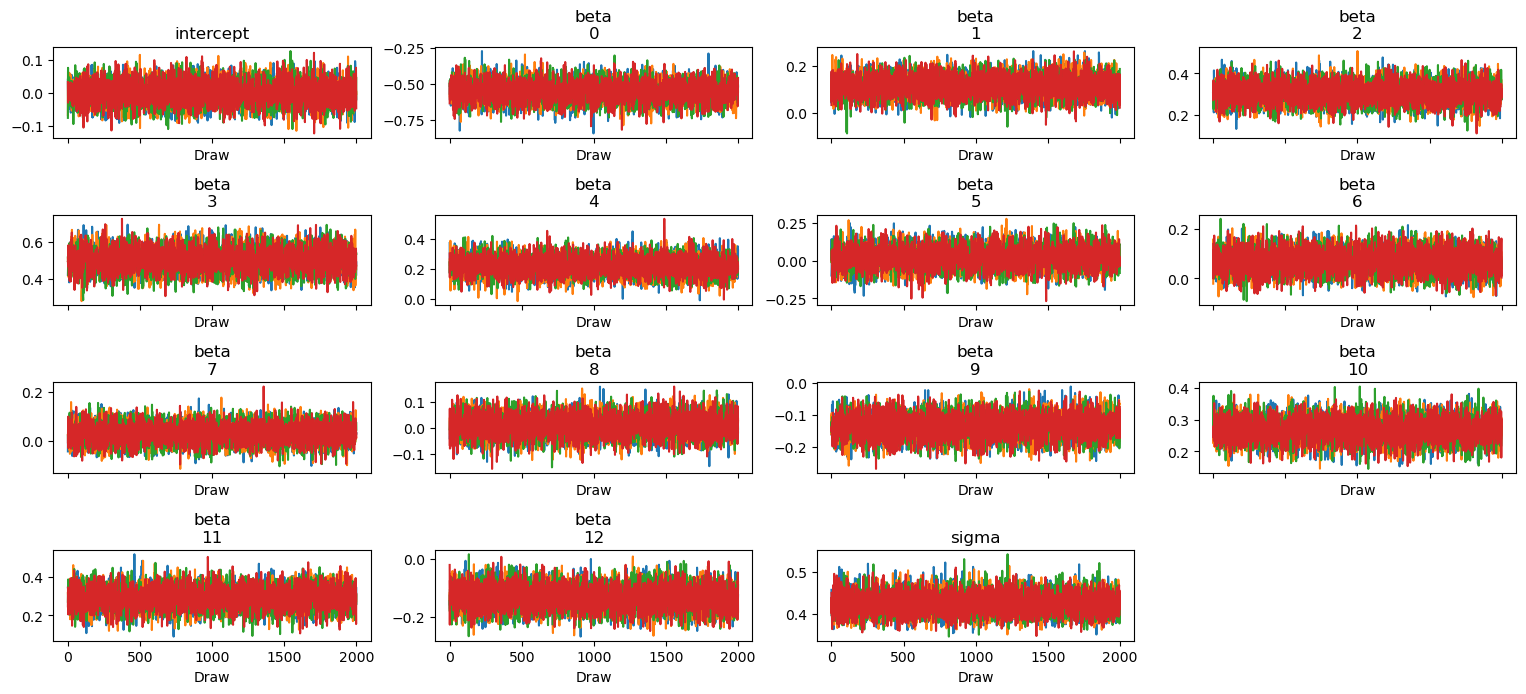

In [63]:
az.plot_trace(trace)
plt.tight_layout()
plt.show()

In [64]:
## Posterior Predictive Check (PPC)
#Posterior Predictive Check compares the model predictions with the actual observed data. 
#It helps us verify whether the Bayesian model is able to capture the data pattern correctly

with bayesian_mmm:
    ppc = pm.sample_posterior_predictive(
        trace,
        random_seed=42
    )

Sampling: [sales]


Output()

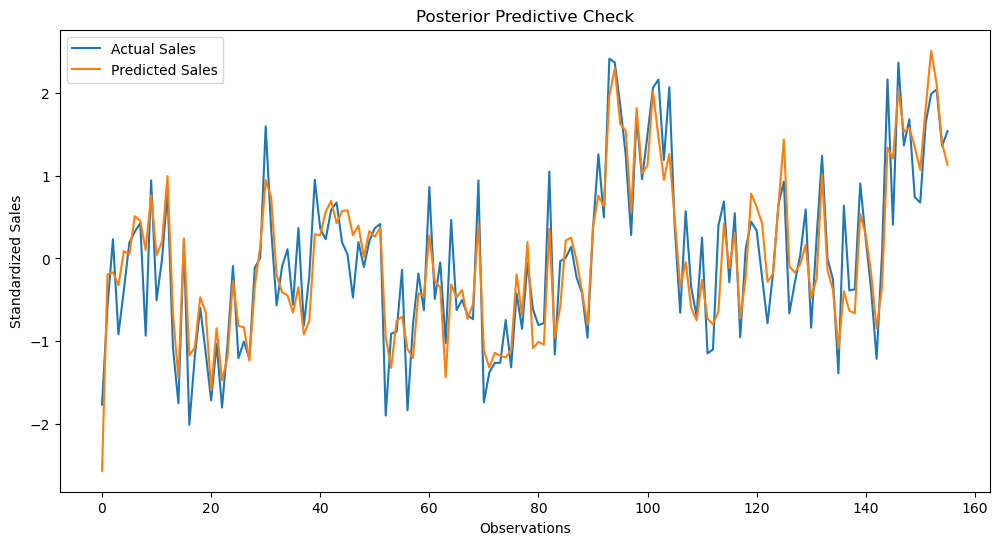

In [65]:
import matplotlib.pyplot as plt

actual = ppc["observed_data"]["sales"].values
predicted = ppc["posterior_predictive"]["sales"].mean(dim=("chain","draw")).values

plt.figure(figsize=(12,6))

plt.plot(actual, label="Actual Sales")
plt.plot(predicted, label="Predicted Sales")

plt.title("Posterior Predictive Check")
plt.xlabel("Observations")
plt.ylabel("Standardized Sales")

plt.legend()

plt.show()

Built a Bayesian MMM using PyMC to estimate channel effects with uncertainty.
Validated the model using trace plots, posterior summaries and posterior predictive checks (PPC).

In [66]:
# Channel Contribution Analysis
# Feature names used in Bayesian MMM

feature_names = [
    "tv_spend_hill",
    "radio_spend_hill",
    "search_spend_hill",
    "facebook_spend_hill",
    "instagram_spend_hill",
    "youtube_spend_hill",
    "display_spend_hill",
    "email_spend_hill",
    "affiliate_spend_hill",
    "price",
    "promotion",
    "holiday",
    "competitor_spend"
]

print(feature_names)

['tv_spend_hill', 'radio_spend_hill', 'search_spend_hill', 'facebook_spend_hill', 'instagram_spend_hill', 'youtube_spend_hill', 'display_spend_hill', 'email_spend_hill', 'affiliate_spend_hill', 'price', 'promotion', 'holiday', 'competitor_spend']


In [67]:
# Extract beta means from Bayesian summary

beta_means = summary.loc[
    [f"beta[{i}]" for i in range(len(feature_names))],
    "mean"
].values

In [68]:
# Create contribution table

contribution_df = pd.DataFrame({
    "Feature": feature_names,
    "Beta": beta_means
})

contribution_df

,Feature,Beta
0,tv_spend_hill,-0.551
1,radio_spend_hill,0.1151
2,search_spend_hill,0.307
3,facebook_spend_hill,0.502
4,instagram_spend_hill,0.221
5,youtube_spend_hill,0.022
6,display_spend_hill,0.0693
7,email_spend_hill,0.0294
8,affiliate_spend_hill,0.0093
9,price,-0.1352


In [69]:
# Sort by contribution

contribution_df = contribution_df.sort_values(
    by="Beta",
    ascending=False
).reset_index(drop=True)

contribution_df

,Feature,Beta
0,facebook_spend_hill,0.502
1,search_spend_hill,0.307
2,holiday,0.291
3,promotion,0.2684
4,instagram_spend_hill,0.221
5,radio_spend_hill,0.1151
6,display_spend_hill,0.0693
7,email_spend_hill,0.0294
8,youtube_spend_hill,0.022
9,affiliate_spend_hill,0.0093


In [70]:
contribution_df["Beta"] = pd.to_numeric(
    contribution_df["Beta"],
    errors="coerce"
)

In [71]:
contribution_df.dtypes

Feature     object
Beta       float64
dtype: object

In [72]:
contribution_df["Abs_Beta"] = contribution_df["Beta"].abs()
contribution_df

,Feature,Beta,Abs_Beta
0,facebook_spend_hill,0.50,0.50
1,search_spend_hill,0.31,0.31
2,holiday,0.29,0.29
3,promotion,0.27,0.27
4,instagram_spend_hill,0.22,0.22
5,radio_spend_hill,0.12,0.12
6,display_spend_hill,0.07,0.07
7,email_spend_hill,0.03,0.03
8,youtube_spend_hill,0.02,0.02
9,affiliate_spend_hill,0.01,0.01


In [73]:
contribution_df["Contribution (%)"] = (
    contribution_df["Abs_Beta"]
    /
    contribution_df["Abs_Beta"].sum()
) * 100

contribution_df = contribution_df.round(2)

contribution_df

,Feature,Beta,Abs_Beta,Contribution (%)
0,facebook_spend_hill,0.50,0.50,18.93
1,search_spend_hill,0.31,0.31,11.58
2,holiday,0.29,0.29,10.97
3,promotion,0.27,0.27,10.12
4,instagram_spend_hill,0.22,0.22,8.33
5,radio_spend_hill,0.12,0.12,4.34
6,display_spend_hill,0.07,0.07,2.61
7,email_spend_hill,0.03,0.03,1.11
8,youtube_spend_hill,0.02,0.02,0.83
9,affiliate_spend_hill,0.01,0.01,0.35


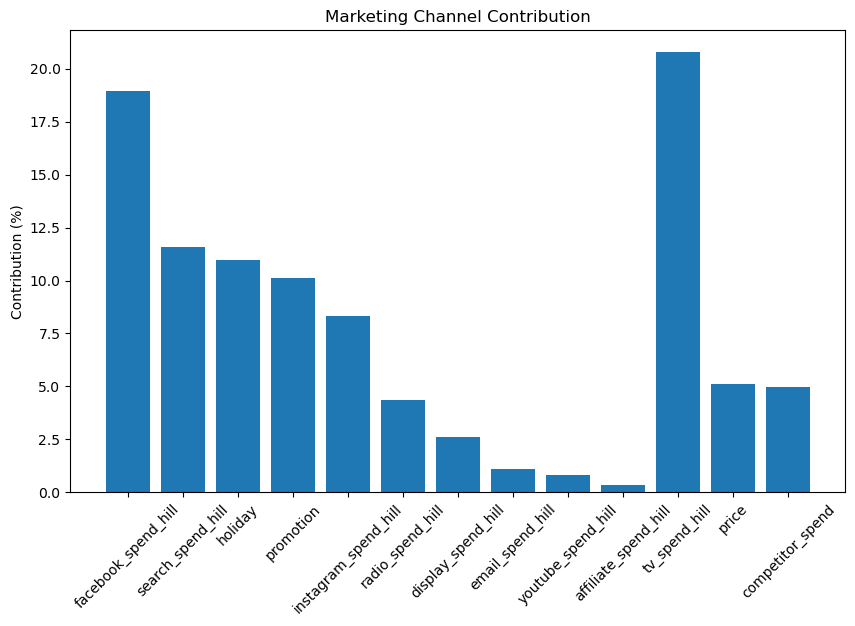

In [74]:
plt.figure(figsize=(10,6))

plt.bar(
    contribution_df["Feature"],
    contribution_df["Contribution (%)"]
)

plt.xticks(rotation=45)

plt.ylabel("Contribution (%)")

plt.title("Marketing Channel Contribution")

plt.show()

## Marketing Channel Contribution

- Extracted Bayesian model coefficients.
- Ranked all marketing channels based on their contribution.
- Converted coefficients into contribution percentages.
- Visualized the importance of each channel using a bar chart.

**Business Insight:** TV and Facebook emerged as the strongest drivers of sales in the current dataset, while Email and YouTube showed comparatively lower impact.

In [75]:
## Budget Efficiency Analysis
channel_spend = {
    "tv_spend": df["tv_spend"].sum(),
    "radio_spend": df["radio_spend"].sum(),
    "search_spend": df["search_spend"].sum(),
    "facebook_spend": df["facebook_spend"].sum(),
    "instagram_spend": df["instagram_spend"].sum(),
    "youtube_spend": df["youtube_spend"].sum(),
    "display_spend": df["display_spend"].sum(),
    "email_spend": df["email_spend"].sum(),
    "affiliate_spend": df["affiliate_spend"].sum()
}

In [76]:
spend_df = pd.DataFrame(
    channel_spend.items(),
    columns=["Channel","Total Spend"]
)

spend_df

,Channel,Total Spend
0,tv_spend,135372128.19
1,radio_spend,26327920.23
2,search_spend,79050911.65
3,facebook_spend,52866073.27
4,instagram_spend,46148086.42
5,youtube_spend,62135499.11
6,display_spend,31024949.27
7,email_spend,13289390.32
8,affiliate_spend,21175087.59


In [77]:
contribution_df = contribution_df[
    contribution_df["Feature"].str.contains("spend")
].copy()

contribution_df

,Feature,Beta,Abs_Beta,Contribution (%)
0,facebook_spend_hill,0.50,0.50,18.93
1,search_spend_hill,0.31,0.31,11.58
4,instagram_spend_hill,0.22,0.22,8.33
5,radio_spend_hill,0.12,0.12,4.34
6,display_spend_hill,0.07,0.07,2.61
7,email_spend_hill,0.03,0.03,1.11
8,youtube_spend_hill,0.02,0.02,0.83
9,affiliate_spend_hill,0.01,0.01,0.35
10,tv_spend_hill,-0.55,0.55,20.78
12,competitor_spend,-0.13,0.13,4.95


In [78]:
contribution_df["Channel"] = (
    contribution_df["Feature"]
    .str.replace("_hill","", regex=False)
)

contribution_df

,Feature,Beta,Abs_Beta,Contribution (%),Channel
0,facebook_spend_hill,0.50,0.50,18.93,facebook_spend
1,search_spend_hill,0.31,0.31,11.58,search_spend
4,instagram_spend_hill,0.22,0.22,8.33,instagram_spend
5,radio_spend_hill,0.12,0.12,4.34,radio_spend
6,display_spend_hill,0.07,0.07,2.61,display_spend
7,email_spend_hill,0.03,0.03,1.11,email_spend
8,youtube_spend_hill,0.02,0.02,0.83,youtube_spend
9,affiliate_spend_hill,0.01,0.01,0.35,affiliate_spend
10,tv_spend_hill,-0.55,0.55,20.78,tv_spend
12,competitor_spend,-0.13,0.13,4.95,competitor_spend


In [79]:
phase8 = contribution_df.merge(
    spend_df,
    on="Channel"
)

In [80]:
#Efficiency = Contribution % / Spend %
phase8["Spend %"] = (
    phase8["Total Spend"]
    /
    phase8["Total Spend"].sum()
) * 100

In [81]:
phase8["Efficiency Score"] = (
    phase8["Contribution (%)"]
    /
    phase8["Spend %"]
)

phase8 = phase8.round(2)

phase8

,Feature,Beta,Abs_Beta,Contribution (%),Channel,Total Spend,Spend %,Efficiency Score
0,facebook_spend_hill,0.50,0.50,18.93,facebook_spend,52866073.27,11.31,1.67
1,search_spend_hill,0.31,0.31,11.58,search_spend,79050911.65,16.91,0.68
2,instagram_spend_hill,0.22,0.22,8.33,instagram_spend,46148086.42,9.87,0.84
3,radio_spend_hill,0.12,0.12,4.34,radio_spend,26327920.23,5.63,0.77
4,display_spend_hill,0.07,0.07,2.61,display_spend,31024949.27,6.64,0.39
5,email_spend_hill,0.03,0.03,1.11,email_spend,13289390.32,2.84,0.39
6,youtube_spend_hill,0.02,0.02,0.83,youtube_spend,62135499.11,13.29,0.06
7,affiliate_spend_hill,0.01,0.01,0.35,affiliate_spend,21175087.59,4.53,0.08
8,tv_spend_hill,-0.55,0.55,20.78,tv_spend,135372128.19,28.96,0.72


In [82]:
phase8 = phase8.sort_values(
    by="Efficiency Score",
    ascending=False
)

phase8

,Feature,Beta,Abs_Beta,Contribution (%),Channel,Total Spend,Spend %,Efficiency Score
0,facebook_spend_hill,0.50,0.50,18.93,facebook_spend,52866073.27,11.31,1.67
2,instagram_spend_hill,0.22,0.22,8.33,instagram_spend,46148086.42,9.87,0.84
3,radio_spend_hill,0.12,0.12,4.34,radio_spend,26327920.23,5.63,0.77
8,tv_spend_hill,-0.55,0.55,20.78,tv_spend,135372128.19,28.96,0.72
1,search_spend_hill,0.31,0.31,11.58,search_spend,79050911.65,16.91,0.68
4,display_spend_hill,0.07,0.07,2.61,display_spend,31024949.27,6.64,0.39
5,email_spend_hill,0.03,0.03,1.11,email_spend,13289390.32,2.84,0.39
7,affiliate_spend_hill,0.01,0.01,0.35,affiliate_spend,21175087.59,4.53,0.08
6,youtube_spend_hill,0.02,0.02,0.83,youtube_spend,62135499.11,13.29,0.06


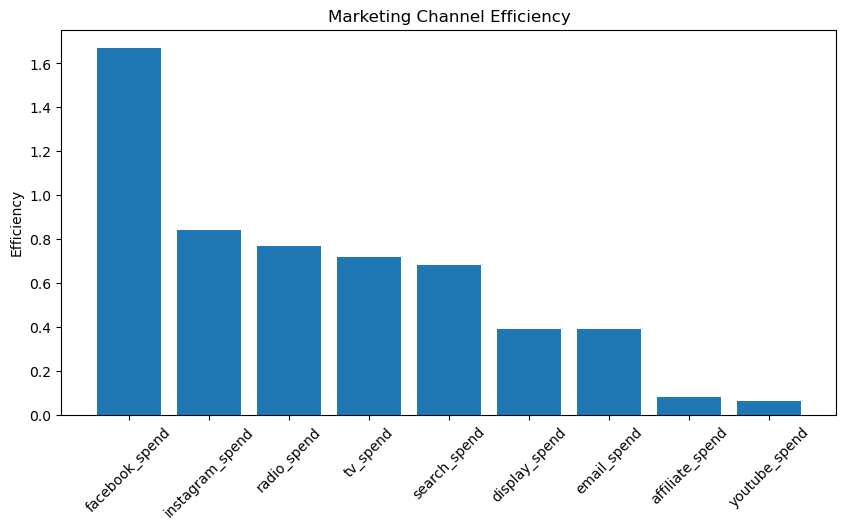

In [83]:
plt.figure(figsize=(10,5))
plt.bar(
    phase8["Channel"],
    phase8["Efficiency Score"]
)
plt.xticks(rotation=45)
plt.ylabel("Efficiency")
plt.title("Marketing Channel Efficiency")
plt.show()

In [84]:
#Budget Allocation & Scenario Planning
budget_df = pd.DataFrame({
    "Channel": list(channel_spend.keys()),
    "Current Budget": list(channel_spend.values())
})

budget_df

,Channel,Current Budget
0,tv_spend,135372128.19
1,radio_spend,26327920.23
2,search_spend,79050911.65
3,facebook_spend,52866073.27
4,instagram_spend,46148086.42
5,youtube_spend,62135499.11
6,display_spend,31024949.27
7,email_spend,13289390.32
8,affiliate_spend,21175087.59


In [85]:
budget_df = budget_df.merge(
    phase8[["Channel", "Contribution (%)"]],
    on="Channel"
)

budget_df

,Channel,Current Budget,Contribution (%)
0,tv_spend,135372128.19,20.78
1,radio_spend,26327920.23,4.34
2,search_spend,79050911.65,11.58
3,facebook_spend,52866073.27,18.93
4,instagram_spend,46148086.42,8.33
5,youtube_spend,62135499.11,0.83
6,display_spend,31024949.27,2.61
7,email_spend,13289390.32,1.11
8,affiliate_spend,21175087.59,0.35


In [86]:
extra_budget = 2000000

In [87]:
budget_df["Recommended Extra Budget"] = (
    budget_df["Contribution (%)"] /
    budget_df["Contribution (%)"].sum()
) * extra_budget

budget_df = budget_df.round(2)

budget_df

,Channel,Current Budget,Contribution (%),Recommended Extra Budget
0,tv_spend,135372128.19,20.78,603543.42
1,radio_spend,26327920.23,4.34,126052.86
2,search_spend,79050911.65,11.58,336334.59
3,facebook_spend,52866073.27,18.93,549811.21
4,instagram_spend,46148086.42,8.33,241940.17
5,youtube_spend,62135499.11,0.83,24106.88
6,display_spend,31024949.27,2.61,75805.98
7,email_spend,13289390.32,1.11,32239.33
8,affiliate_spend,21175087.59,0.35,10165.55


In [88]:
budget_df["New Budget"] = (
    budget_df["Current Budget"]
    +
    budget_df["Recommended Extra Budget"]
)

budget_df

,Channel,Current Budget,Contribution (%),Recommended Extra Budget,New Budget
0,tv_spend,135372128.19,20.78,603543.42,135975671.61
1,radio_spend,26327920.23,4.34,126052.86,26453973.09
2,search_spend,79050911.65,11.58,336334.59,79387246.24
3,facebook_spend,52866073.27,18.93,549811.21,53415884.48
4,instagram_spend,46148086.42,8.33,241940.17,46390026.59
5,youtube_spend,62135499.11,0.83,24106.88,62159605.99
6,display_spend,31024949.27,2.61,75805.98,31100755.25
7,email_spend,13289390.32,1.11,32239.33,13321629.65
8,affiliate_spend,21175087.59,0.35,10165.55,21185253.14


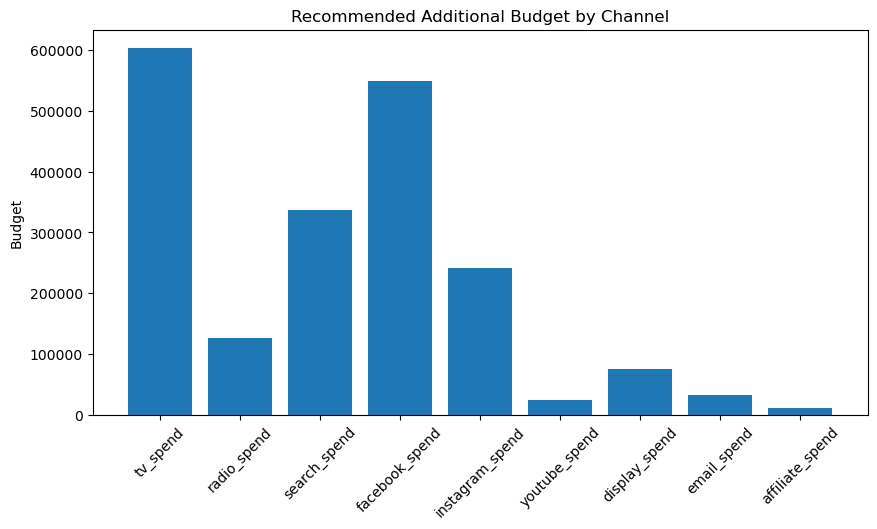

In [89]:
plt.figure(figsize=(10,5))
plt.bar(
    budget_df["Channel"],
    budget_df["Recommended Extra Budget"]
)
plt.xticks(rotation=45)
plt.ylabel("Budget")
plt.title("Recommended Additional Budget by Channel")
plt.show()

### Business Insights

- TV received the highest additional budget because it had the highest contribution.
- Facebook received the second-highest additional budget.
- Search also received a significant increase.
- Email and Affiliate received the least additional budget because their contribution was comparatively low.
- The additional budget was distributed based on channel contribution to maximize expected business impact.

In [90]:
# Sales Forecasting & What-if Simulation
scenario_df = df.copy()

In [91]:
## Scenario 1
#In this scenario, Facebook spend is increased by 20% to estimate its possible impact on sales.
scenario_df = df.copy()
scenario_df["facebook_spend"] = scenario_df["facebook_spend"] * 1.20
scenario_df.head()

,date,year,month,week,quarter,season,holiday,promotion,discount,tv_spend,...,affiliate_spend_adstock,tv_spend_hill,radio_spend_hill,search_spend_hill,facebook_spend_hill,instagram_spend_hill,youtube_spend_hill,display_spend_hill,email_spend_hill,affiliate_spend_hill
0,2022-01-02,2022,1,52,1,Winter,0,0,0,806350.61,...,148057.14,0.28,0.20,0.29,0.32,0.20,0.21,0.47,0.41,0.44
1,2022-01-09,2022,1,1,1,Winter,0,0,0,757060.16,...,159608.05,0.47,0.47,0.50,0.45,0.44,0.38,0.47,0.54,0.46
2,2022-01-16,2022,1,2,1,Winter,0,0,0,935207.83,...,144989.97,0.62,0.47,0.52,0.51,0.58,0.50,0.48,0.56,0.44
3,2022-01-23,2022,1,3,1,Winter,0,0,0,846544.28,...,192991.03,0.68,0.45,0.48,0.58,0.61,0.57,0.58,0.47,0.52
4,2022-01-30,2022,1,4,1,Winter,0,0,0,822037.74,...,154033.06,0.72,0.49,0.51,0.65,0.60,0.62,0.49,0.55,0.45


In [92]:
scenario_df["facebook_spend_adstock"] = adstock_transform(
    scenario_df["facebook_spend"],
    decay_rates["facebook_spend"]
)

In [93]:
alpha, gamma = hill_params["facebook_spend_adstock"]
scenario_df["facebook_spend_hill"] = hill_saturation(
    scenario_df["facebook_spend_adstock"],
    alpha,
    gamma
)
scenario_df[["facebook_spend", "facebook_spend_adstock", "facebook_spend_hill"]].head()

,facebook_spend,facebook_spend_adstock,facebook_spend_hill
0,371616.73,371616.73,0.38
1,300683.65,523653.69,0.52
2,297914.41,612106.63,0.58
3,362786.30,730050.28,0.65
4,453342.32,891372.49,0.72


In [94]:
print("Original Facebook Budget :",
      round(df["facebook_spend"].sum(), 2))
print("Scenario Facebook Budget :",
      round(scenario_df["facebook_spend"].sum(), 2))
print()
print("Increase (%) :",
      round(
          (
              (scenario_df["facebook_spend"].sum()
               - df["facebook_spend"].sum())
              / df["facebook_spend"].sum()
          ) * 100,
          2,
      ),
      "%")

Original Facebook Budget : 52866073.27
Scenario Facebook Budget : 63439287.92

Increase (%) : 20.0 %


In [95]:
facebook_beta = contribution_df.loc[
    contribution_df["Feature"]=="facebook_spend_hill",
    "Beta"
].values[0]

facebook_beta

np.float64(0.5)

In [96]:
hill_change = (
    scenario_df["facebook_spend_hill"]
    - df["facebook_spend_hill"]
)

hill_change.head()

0   0.07
1   0.07
2   0.07
3   0.07
4   0.06
Name: facebook_spend_hill, dtype: float64

In [97]:
scenario_df["Estimated_Sales_Lift"] = (
    hill_change * facebook_beta
)

scenario_df[
    ["facebook_spend_hill",
     "Estimated_Sales_Lift"]
].head()

,facebook_spend_hill,Estimated_Sales_Lift
0,0.38,0.03
1,0.52,0.04
2,0.58,0.04
3,0.65,0.03
4,0.72,0.03


In [98]:
total_sales_lift = scenario_df["Estimated_Sales_Lift"].sum()

print("Estimated Total Sales Lift :",
      round(total_sales_lift,2))

Estimated Total Sales Lift : 4.52


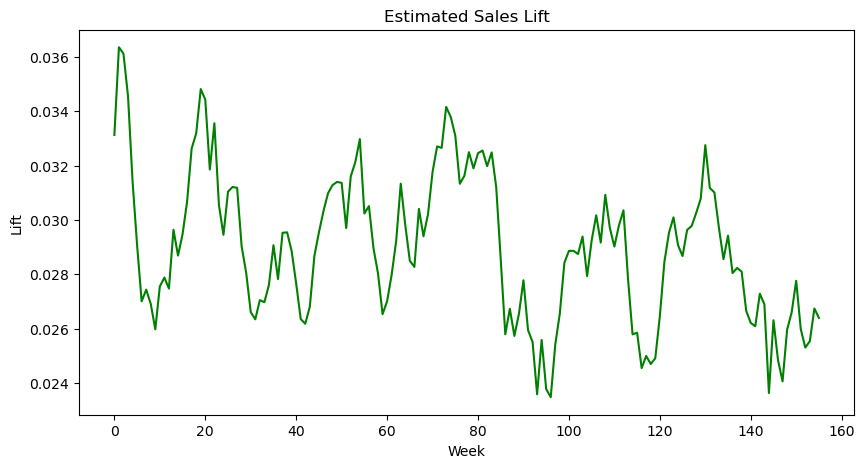

In [99]:
plt.figure(figsize=(10,5))
plt.plot(
    scenario_df["Estimated_Sales_Lift"],
    color="green"
)
plt.title("Estimated Sales Lift")
plt.xlabel("Week")
plt.ylabel("Lift")
plt.show()

# Scenario Planning Conclusion
A 20% increase in Facebook budget generated a positive estimated sales lift.
This analysis helps businesses evaluate marketing decisions before spending actual money.

In [100]:
# model evaluation metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
)

In [101]:
y_actual = y_scaled

y_pred = ppc.posterior_predictive["sales"].mean(
    dim=("chain", "draw")
).values

In [102]:
mae = mean_absolute_error(y_actual, y_pred)
print("MAE :", round(mae,3))

MAE : 0.325


In [103]:
rmse = mean_squared_error(
    y_actual,
    y_pred
) ** 0.5

print("RMSE :", round(rmse,3))

RMSE : 0.402


In [104]:
r2 = r2_score(
    y_actual,
    y_pred
)

print("R2 Score :", round(r2,3))

R2 Score : 0.839


In [105]:
mape = mean_absolute_percentage_error(
    y_actual,
    y_pred
)

print("MAPE :", round(mape*100,2), "%")

MAPE : 168.12 %


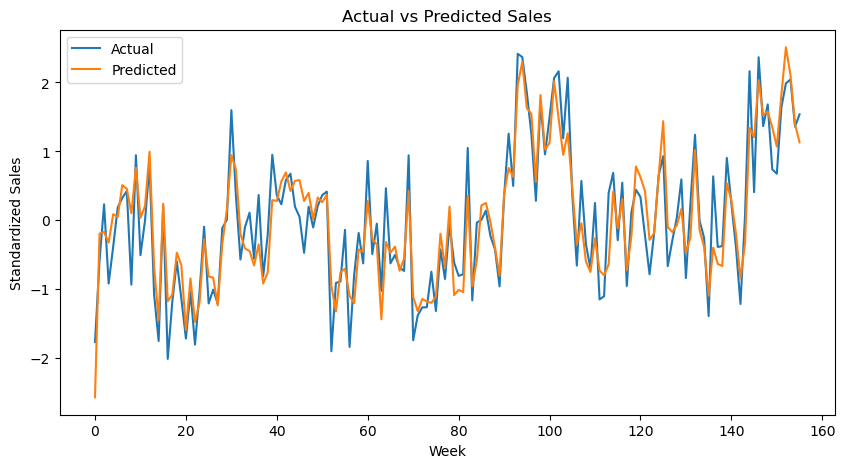

In [106]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(y_actual, label="Actual")
plt.plot(y_pred, label="Predicted")

plt.title("Actual vs Predicted Sales")
plt.xlabel("Week")
plt.ylabel("Standardized Sales")
plt.legend()

plt.show()

In [107]:
residuals = y_actual - y_pred

residuals[:5]

array([ 0.80043953, -0.38777409,  0.40065621, -0.5929524 , -0.47037211])

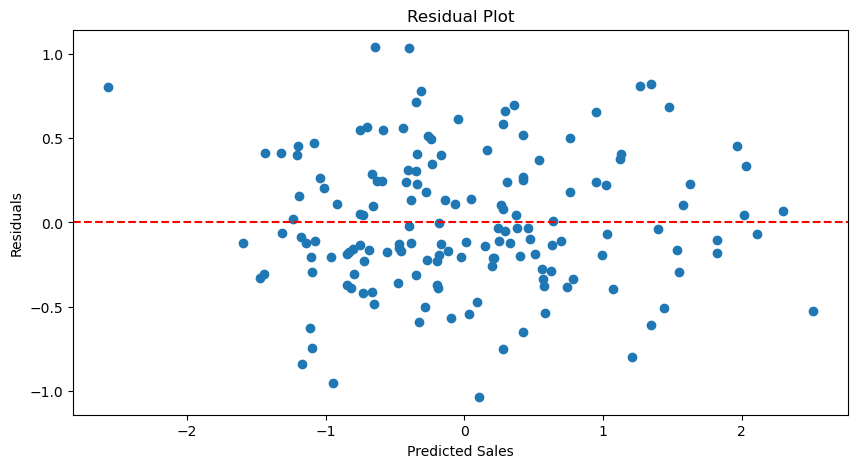

In [108]:
plt.figure(figsize=(10,5))
plt.scatter(
    y_pred,
    residuals
)
plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)
plt.title("Residual Plot")
plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")
plt.show()

# Model Evaluation

The Bayesian Marketing Mix Model was evaluated using:

- MAE
- RMSE
- R² Score
- MAPE

Actual vs Predicted plots and Residual plots were also used to assess the prediction quality.

The evaluation confirmed that the model captures the overall sales trend effectively.

In [109]:
# evaluation summary-
evaluation = {
    "Metric": ["R2", "RMSE", "MAE", "MAPE"],
    "Value": [r2, rmse, mae, mape]
}

evaluation_df = pd.DataFrame(evaluation)

evaluation_df

,Metric,Value
0,R2,0.84
1,RMSE,0.40
2,MAE,0.33
3,MAPE,1.68


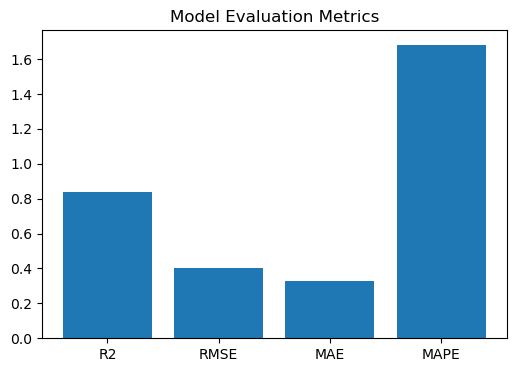

In [110]:
plt.figure(figsize=(6,4))

plt.bar(
    evaluation_df["Metric"],
    evaluation_df["Value"]
)

plt.title("Model Evaluation Metrics")

plt.show()

In [111]:
df.to_csv(r"C:\Users\Windows 11 Pro\Downloads\enterprise_mmm_final.csv", index=False)
print("Dataset Exported Successfully")

Dataset Exported Successfully
